**Importing required Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

data = pd.read_csv("ott_dataset.csv")
print(f"Shape of Data : {data.shape}")

Shape of Data : (8807, 12)


**Data Info**

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


**Checking Unique Attributes**

In [ ]:
data.nunique()

,0
show_id,8807
type,2
title,8807
director,4528
cast,7692
country,748
date_added,1767
release_year,74
rating,17
duration,220


**Statistics Checking**

In [ ]:
data.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


**Sample Rows of Dataset**

In [ ]:
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


**Data Cleaning and Pre Processing**

In [ ]:
# Data Cleaning

data_dup = data.copy() # creating a copy of original data

# Functions used for Data Cleaning

def encode(data):
  data = str(data)
  return int(data.split(", ")[1])

def conv(data):
  data = str(data)
  return data

def datefill(value):
  return value.year

def gen_split(record):
  if ", " in record :
    return record.split(", ")
  else :
    return record

#1. Related to date_added column, there are 10 missing values in the column
#   NaN data is being replaced after analysing release_year and date_added of other rows
#   No of records with added_year other than release_year is more
#   Imputation is done based on average year difference between added_year and release_year columns


date_null = data[~(data["date_added"].isna())]
data["added_year"] = date_null["date_added"].apply(encode)

same_year = data[data["release_year"]==data["added_year"]]
other_year = data[data["release_year"]!=data["added_year"]]

data["year_diff"] = data["added_year"] - data["release_year"]
data["date_added"] = data["date_added"].str.strip()
data["date_added"] = pd.to_datetime(data["date_added"])

fill_value = (pd.to_datetime(data["release_year"].apply(conv)) + pd.DateOffset(years=np.round(data["year_diff"].mean()))).dt.strftime('%Y-%m-%d')
data["date_added"].fillna(fill_value, inplace=True)

# 2. Replacing rating NaN values

data["rating"].fillna(data.loc[data["type"]=="Movie"]["rating"].mode()[0], inplace=True)
data["rating"].fillna(data.loc[data["type"]=="TV Show"]["rating"].mode()[0], inplace=True)

#3. Cleaning Rating column with duration values and filling Duration NaN values

err_data = data[data["rating"].isin(["74 min","84 min","66 min"])]
err_data["duration"] = err_data["rating"]
err_data["rating"] = data["rating"].mode()[0]
data = pd.concat([data,err_data], ignore_index = True)
data.drop([5541,5794,5813], axis =0, inplace=True) # Removing duplicate rows

#4. Country NaN Imputation

# Unnesting Cast

cast_data = data[["title","cast"]]
cast_data["unnest_data"] = cast_data["cast"].str.split(", ")
cast_data = cast_data.explode("unnest_data")
data = pd.merge(left=data, right=cast_data, on="title")
data.drop("cast_y",axis=1,inplace=True)
data.rename(columns={"cast_x":"cast"},inplace=True)

#Unnesting Country

country_df = data[["title","country"]]
country_df["unnest_country"] = country_df["country"].str.split(", ")
country_df = country_df.explode("unnest_country")
data = pd.merge(left=data,right=country_df,on="title")
data.drop("country_y",axis=1,inplace=True)
data.rename(columns={'country_x':'country'}, inplace=True)


#Unnesting Genre

genre_data = data[["title","listed_in"]]
genre_data["unnest_genre"] = genre_data["listed_in"].apply(gen_split)
genre_data = genre_data.explode("unnest_genre")
data = pd.merge(left=data, right=genre_data, on="title")
data.drop("listed_in_y",axis=1,inplace=True)
data.rename(columns={'listed_in_x':'listed_in'}, inplace=True)

movies_data = data[data["type"]=="Movie"]
tv_data = data[data["type"]=="TV Show"]

movie_country = movies_data["unnest_country"].mode()[0]
tv_country = tv_data["unnest_country"].mode()[0]

# As mode on country for both movie data and TV Show data is United States imputing the same with country NaN values

data["country"].fillna(movie_country,inplace=True)

# 5. Cast NaN imputation based on highest movies made by actor in country

data["unnest_country"].fillna("United States",inplace=True)
data["country"].fillna("United States", inplace=True)

data_c5 = data.groupby(["type","unnest_country"])["unnest_data"].value_counts().sort_values(ascending=False).reset_index()
df_test = data_c5.groupby(["unnest_country","type","unnest_data"])["count"].max().sort_values(ascending=False).reset_index()
dict_cast = {"Movie":{},"TV Show":{}}
for i in data_c5["unnest_country"].unique():
  if df_test[df_test["unnest_country"]==i].head(1).values[0][1]=="Movie":
    dict_cast["Movie"][i]=df_test[df_test["unnest_country"]==i].head(1).values[0][2]
  else:
    dict_cast["TV Show"][i]=df_test[df_test["unnest_country"]==i].head(1).values[0][2]
  # print(df_test[df_test["unnest_country"]==i].head(1).values[0][1])
  continue


#print(dict_cast)
for main_key in dict_cast.keys():
  for key in dict_cast[main_key].keys():
    dummy_df = data[data["unnest_country"]==key]
    dummy_df["cast"].fillna(dict_cast[main_key][key],inplace=True)
    dummy_df["unnest_data"].fillna(dict_cast[main_key][key],inplace=True)
    data = pd.concat([data,dummy_df],ignore_index=True)

#6. Director NaN imputation based on highest movies directed by him in country

data_c6 = data.groupby(["type","unnest_country"])["director"].value_counts().sort_values(ascending=False).reset_index()

df_test1 = data_c6.groupby(["type","unnest_country","director"])["count"].max().sort_values(ascending=False).reset_index()

dict_cast = {"Movie":{},"TV Show":{}}
for i in data_c6["unnest_country"].unique():
  if df_test1[df_test1["unnest_country"]==i].head(1).values[0][1]=="Movie":
    dict_cast["Movie"][i]=df_test1[df_test1["unnest_country"]==i].head(1).values[0][2]
  else:
    dict_cast["TV Show"][i]=df_test1[df_test1["unnest_country"]==i].head(1).values[0][2]
  # print(df_test[df_test["unnest_country"]==i].head(1).values[0][1])
  continue


#print(dict_cast)
for main_key in dict_cast.keys():
  for key in dict_cast[main_key].keys():
    dummy_df = data[data["unnest_country"]==key]
    dummy_df["director"].fillna(dict_cast[main_key][key],inplace=True)
    data = pd.concat([data,dummy_df],ignore_index=True)

# Dropping all duplicate records

data.drop_duplicates(ignore_index=True, inplace=True)

data["added_year"] = data["date_added"].apply(datefill)
data["year_diff"] = data["added_year"] - data["release_year"]

# As we have replaced all possible NaN records and dropped duplicate records
# Now we are dropping the rows with NaN records

data.dropna(axis=0, ignore_index=True,inplace=True)


**Visual analysis using plots**

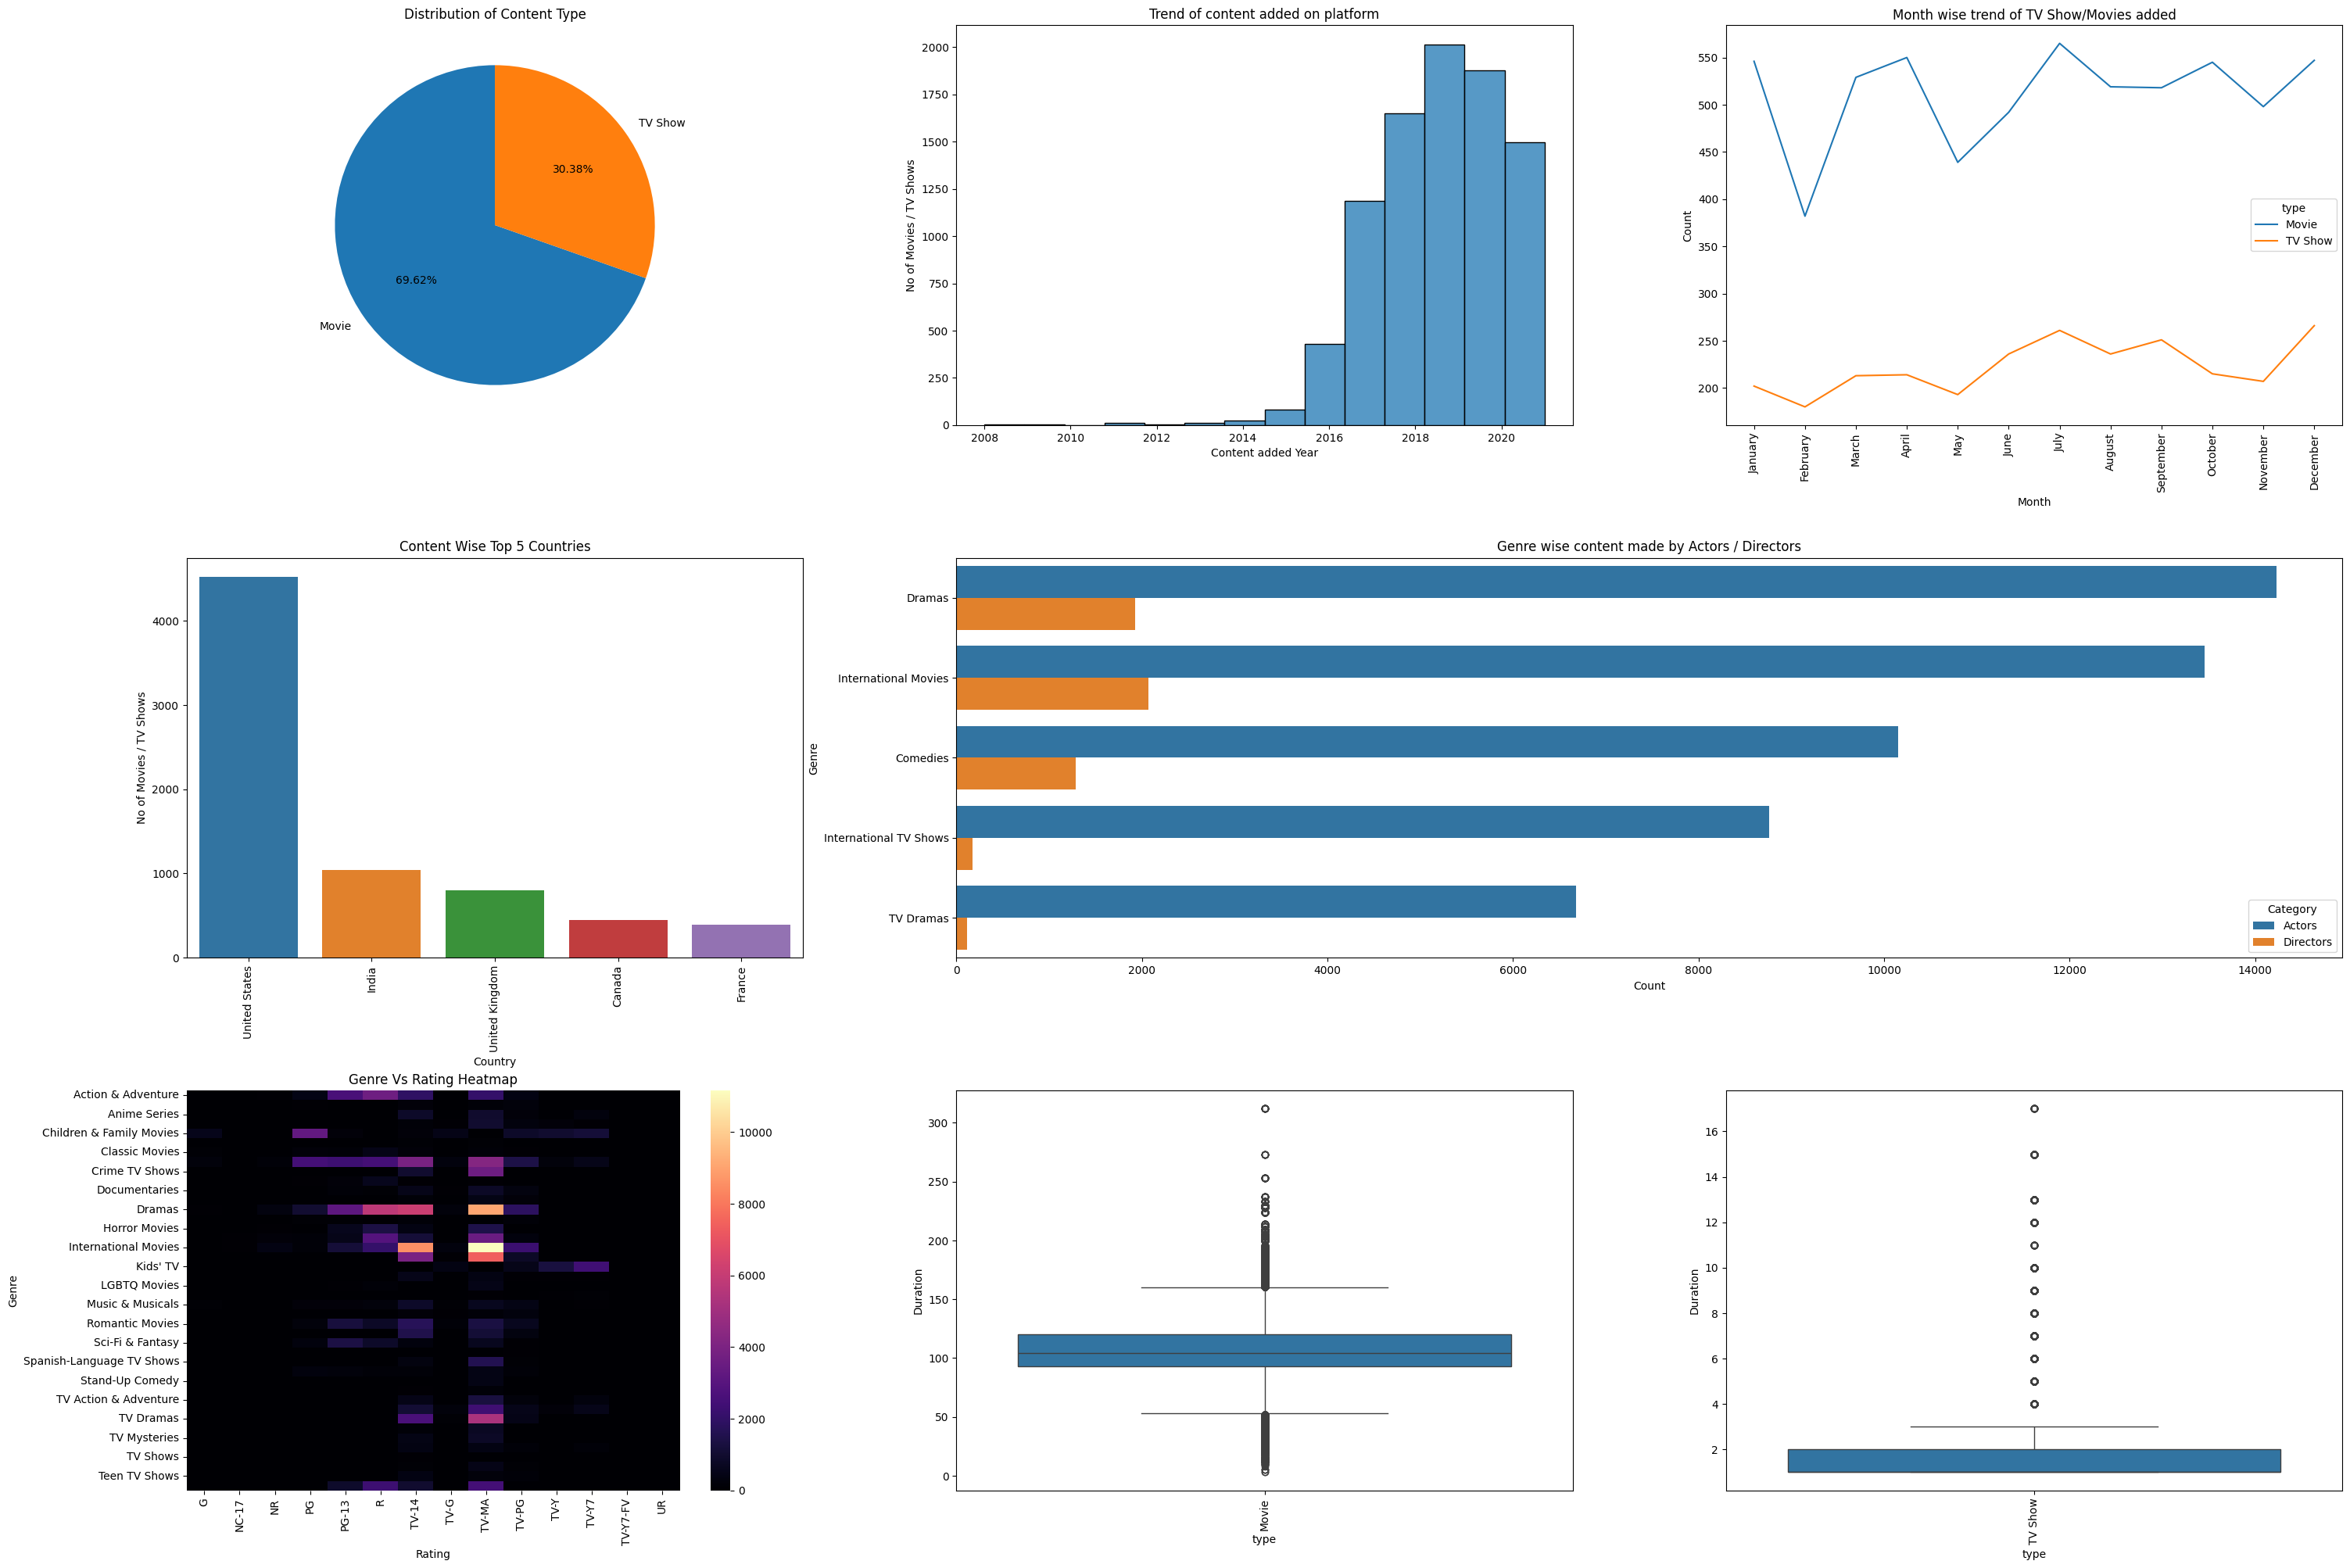

In [ ]:
def time_con(dur):
  return int(dur[0])

fig = plt.figure(figsize=(30, 20))

plt.subplot(3,3,1)
type_content = data_dup["type"].value_counts()
plt.pie(type_content, labels= type_content.index, startangle=90, autopct = '%.2f%%')
plt.title("Distribution of Content Type")


plt.subplot(3,3,2)
date_null = data_dup[~(data_dup["date_added"].isna())]
data_dup["added_year"] = date_null["date_added"].apply(encode)
sns.histplot(data_dup["added_year"], bins=14) # Univariate plot for continuous variable
plt.xlabel("Content added Year")
plt.ylabel("No of Movies / TV Shows")
plt.title("Trend of content added on platform")


plt.subplot(3,3,3)
tv_data = data.copy()
tv_data["Month"] = tv_data["date_added"].dt.month_name()
tv_data["mon_no"] = tv_data["date_added"].dt.month
line_data = tv_data.groupby(["Month","mon_no","type"])["title"].nunique().reset_index().sort_values(by="mon_no")
line_data.rename(columns={"title":"Count"},inplace=True)
sns.lineplot(data=line_data, x="Month", y="Count",hue="type")
plt.xticks(rotation=90)
plt.title("Month wise trend of TV Show/Movies added")


plt.subplot(3,3,4)
country_wise = data.groupby("unnest_country")["title"].nunique().sort_values(ascending=False).reset_index()
country_wise.rename(columns={"unnest_country":"Country", "title":"Count"}, inplace=True)
sns.barplot(data=country_wise.head(5), x="Country", y="Count", hue="Country")
plt.ylabel("No of Movies / TV Shows")
plt.xticks(rotation=90)
plt.title("Content Wise Top 5 Countries")


plt.subplot(3,3,(5,6))
genre_data = data.groupby("unnest_genre")[["unnest_data","director"]].nunique().sort_values(by=["unnest_data","director"],ascending=[False,False]).reset_index()
top_10 = genre_data.head(5)
top_10.rename(columns ={"unnest_genre":"Genre", "unnest_data":"Actors", "director":"Directors"}, inplace=True)
top_10 = pd.melt(top_10, id_vars="Genre", var_name ="Category", value_name="Count")
sns.barplot(top_10, x="Count", y="Genre",hue="Category")
plt.title("Genre wise content made by Actors / Directors")

plt.subplot(3,3,7)
sns.heatmap((pd.crosstab(data["unnest_genre"],data["rating"])), cmap ="magma")
plt.xlabel("Rating")
plt.ylabel("Genre")
plt.title("Genre Vs Rating Heatmap")


plt.subplot(3,3,8)
movies_data = data[data["type"]=="Movie"]
tvs_data = data[data["type"]=="TV Show"]
movies_data["duration_min"] = movies_data["duration"].str.split().apply(time_con)
sns.boxplot(data=movies_data, y = "duration_min", x= "type")
plt.ylabel("Duration")
plt.xticks(rotation=90)


plt.subplot(3,3,9)
tvs_data["duration_min"] = tvs_data["duration"].str.split().apply(time_con)
sns.boxplot(data=tvs_data, y = "duration_min", x= "type")
plt.ylabel("Duration")
plt.xticks(rotation=90)


fig.tight_layout(pad=0.5)

plt.show()



**Non Graphical using queries**

In [ ]:
share_data = data.groupby("unnest_country")["title"].nunique().sort_values(ascending=False).reset_index()
# x[x['title']>x['title'].mean()]['title']/x["title"].sum()*100
share_data["Share"] = np.round(share_data['title']/share_data["title"].sum()*100,2)
share_data.rename(columns={"unnest_country":"Country","title":"Count"}, inplace = True)
print(share_data.head())

          Country  Count  Share
0   United States   4520  41.73
1           India   1046   9.66
2  United Kingdom    804   7.42
3          Canada    445   4.11
4          France    393   3.63


In [ ]:
avg_dur = np.round(movies_data["duration"].str.split().apply(time_con).mean())
avg_sea = np.round(tvs_data["duration"].str.split().apply(time_con).mean())
print(f"Average Movie duration is : {avg_dur} min")
print(f"Average TV Shows Seasons is : {avg_sea} seasons")

Average Movie duration is : 105.0 min
Average TV Shows Seasons is : 2.0 seasons


In [ ]:
actors = data.groupby("unnest_data")["title"].nunique().sort_values(ascending=False).reset_index()
directors = data.groupby("director")["title"].nunique().sort_values(ascending=False).reset_index()

top_actors = actors.head(300)["title"].sum()
ta_per = top_actors/data_dup["title"].nunique()*100

top_directors = directors.head(400)["title"].sum()
td_per = top_directors/data_dup["title"].nunique()*100
print(f"Out of {len(actors)} actors less than 1 % of the actors constitutes for {np.round(ta_per)} % of total Movies or TV Shows")
print(f"Out of {len(directors)} directors less than 10 % of the directors constitutes for {np.round(td_per)} % of total Movies or TV Shows")

Out of 36436 actors less than 1 % of the actors constitutes for 60.0 % of total Movies or TV Shows
Out of 4527 directors less than 10 % of the directors constitutes for 51.0 % of total Movies or TV Shows


<Axes: ylabel='added_year'>

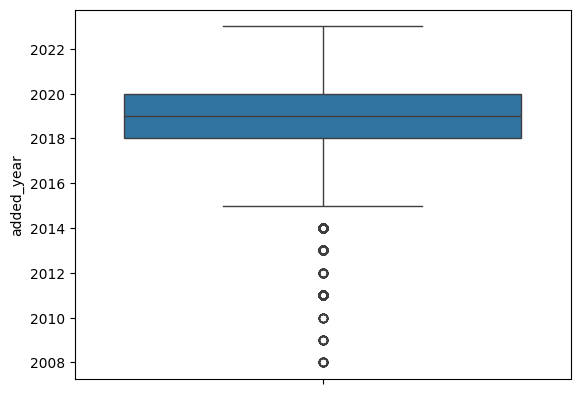

In [ ]:
sns.boxplot(data["added_year"])

In [1]:
!python --version

Python 3.10.12
